This Colab notebook is an accompaniment to my blog post [Fine-Tuning with Graph Neural Networks for Sentiment Analysis](https://linmalin.medium.com/fine-tuning-with-graph-neural-networks-for-sentiment-analysis-342270a99ca5).

This notebook covers the full pipeline development of the sentiment analysis branch.

# Setup environment

### Connect to GPU

In [1]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Wed Apr 15 20:14:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Install libs

In [3]:
!pip install torch-geometric
!pip install stanza
!apt install libgraphviz-dev
!pip install pygraphviz
!pip install datasets
!pip install torch torchvision torchaudio
!pip install tqdm
!pip install requests
!pip install importlib-metadata
!pip install filelock
!pip install sklearn
!pip install tokenizers
!pip install torch-scatter -f https://pytorch-geometric.com/whl/torch-2.5.1+cu121.html

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk librsvg2-common
  libxcomposite1 libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgraphviz-dev
  libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  librsvg2-common libxcomposite1 libxdot4
0 upgraded, 12 newly installed, 0 to remove and 42 not upgraded.
Need to get 2,496 kB of archives.
After this operation, 7,963 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-data all 2.36.0-3build1 [2,824 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-0 amd64 2.36.0-3build1 [51.9 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libgtk2

### Import libs

In [3]:
import torch
import numpy as np
import networkx as nx
import random
import re
import pickle
import time
import copy
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd

from torch import nn
import torch.nn.functional as F

from networkx.drawing.nx_agraph import graphviz_layout
from sklearn.metrics.pairwise import cosine_similarity
from transformers import BertTokenizer, BertModel

In [4]:
def seed_everything(seed=777):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

# Set seed
seed_everything()

####################
# Constants
####################

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

UNIVERSAL_DEPENDENCY_RELATIONS = {'nsubj': 0, 'cop': 1, 'det': 2, 'amod': 3, 'nmod': 4, 'punct': 5, 'case': 6, 'conj': 7, 'cc': 8, 'xcomp': 9, 'advmod': 10, 'advcl:relcl': 11, 'advcl': 12, 'aux': 13, 'obj': 14, 'obl': 15, 'mark': 16, 'nsubj:pass': 17, 'aux:pass': 18, 'compound': 19, 'nmod:poss': 20, 'list': 21, 'appos': 22, 'nummod': 23, 'acl:relcl': 24, 'parataxis': 25, 'obl:npmod': 26, 'csubj': 27, 'acl': 28, 'reparandum': 29, 'flat': 30, 'iobj': 31, 'obl:agent': 32, 'nsubj:outer': 33, 'cc:preconj': 34, 'expl': 35, 'fixed': 36, 'compound:prt': 37, 'dislocated': 38, 'orphan': 39, 'discourse': 40, 'ccomp': 41, 'det:predet': 42, 'vocative': 43, 'obl:tmod': 44, 'nmod:npmod': 45, 'nmod:tmod': 46, 'csubj:outer': 47, 'dep': 48, 'csubj:pass': 49}

BERT_HIDDEN_SIZE = 768

N_SENTIMENT_CLASSES = 2

TQDM_DISABLE=False

In [5]:
UNIVERSAL_DEPENDENCY_RELATIONS.update({
    "obl:unmarked": 50,
    "nmod:unmarked": 51,
    "goeswith": 52
})

# Data preprocessing

In this section, we first define the dataset class, followed by data loading, for which you'll find two options.

## Define a [PyG Dataset](https://pytorch-geometric.readthedocs.io/en/2.6.1/generated/torch_geometric.data.Dataset.html?highlight=dataset#torch-geometric-data-dataset)

In [16]:
from torch_geometric.data import Dataset, Data

class SentenceClassificationGraphDataset(Dataset):
    def __init__(self, raw_data):
        super().__init__()
        self.tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
        self.dataset = self.generate_data(raw_data)

    def len(self):
        return len(self.dataset)

    def get(self, idx):
        return self.dataset[idx]

    def get_glove_embedding(self, words):
        try:
          embedding_vectors = [node_embeddings[word] for word in words]
          return torch.tensor(embedding_vectors, dtype=torch.float)
        except:
          return None # Ignore if the word does not exist in GloVe

    def get_bert_encodings(self, sents):
        print(f"Processing {len(sents)} samples for BERT encodings")
        encoding = self.tokenizer(sents,
                                  return_tensors="pt",
                                  padding=True,
                                  truncation=True,
                                  return_attention_mask=True,
                                  max_length=512)
        input_ids = torch.LongTensor(encoding['input_ids'])
        attention_mask = torch.LongTensor(encoding['attention_mask'])
        print(f"BERT encodings processed.")
        return input_ids, attention_mask

    def get_edge_type(self, G):
        edge_labels = nx.get_edge_attributes(G, 'label')

        result = []
        for label in edge_labels.values():
            if label not in UNIVERSAL_DEPENDENCY_RELATIONS:
                print("UNKNOWN LABEL:", repr(label))
                continue  # ❗ НЕ добавляем None
            result.append(UNIVERSAL_DEPENDENCY_RELATIONS[label])

        return torch.tensor(result, dtype=torch.long)

    def process_raw_data(self, dataset):
        sentiment_data = []
        num_labels = {}
        for split in dataset.keys():
          for record in dataset[split]:
              sent = record['sentence'].strip()
              sent = re.sub(r"[./\\-]", "", sent) + "."
              sent_id = record['id']
              label = record['sentiment']
              if label not in num_labels:
                  num_labels[label] = len(num_labels)
              sentiment_data.append((sent, label, sent_id, split))
        return sentiment_data, num_labels

    def generate_data(self, raw_data):
        data, _ = self.process_raw_data(raw_data)
        print(f"Total number of raw data: {len(data)}")
        sents = [x[0] for x in data]
        input_ids, attention_mask = self.get_bert_encodings(sents)

        graph_embs = []
        for i, (sent, label, sent_id, split) in enumerate(data):
          sent = sent.lower()
          G = create_graph(sent)

          if G is None:
            continue

          nodes = sorted(G.nodes(data=True)) # Sort by node id
          words = [node[1]['label'] for node in nodes]
          xpos = [node[1]['xpos'] for node in nodes]

          x = self.get_glove_embedding(words)
          if x is None:
            continue

          edge_index = torch.tensor(list(G.edges), dtype=torch.long).t().contiguous()

          data = Data(x=x, edge_index=edge_index)
          data.edge_type = self.get_edge_type(G)
          data.node_pos = xpos
          data.y = torch.tensor(label, dtype=torch.long) if label is not None else None
          data.root = G.graph['root']
          data.sent = sent
          data.sent_id = sent_id
          data.sent_input_id = input_ids[i]
          data.sent_attention_mask = attention_mask[i]
          data.split = split

          data = data.to(device)
          graph_embs.append(data)

        print(f"Processed {len(graph_embs)} graph examples")

        return graph_embs



---


Below are two options:
1. download the dataset directly,
2. or, create a dataset from scratch.

Choose the option that best suits your goal.


---


## Option 1: download the processed dataset directly.

A [PyG Dataset](https://pytorch-geometric.readthedocs.io/en/2.6.1/generated/torch_geometric.data.Dataset.html?highlight=dataset#torch-geometric-data-dataset) has created for you. Run the code below to download it to your notebook runtime folder.


- *Please note that this dataset contains two additional attributes—node weights and edge weights—which are not shown in the Dataset class above. **You can ignore them**. I am currently working to incorporate these attributes and conduct experiments to assess their impact.*

## Option 2 (skip if you have done option 1): construct the dataset from scratch (Estimate 30 minutes on T4)


### Download the raw data

In [ ]:
import pandas as pd
import re
import emoji
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

############################
# 1. Загрузка данных
############################
df = pd.read_csv("training.1600000.processed.noemoticon.csv", encoding='latin-1')
df.columns = ['target', 'id', 'date', 'flag', 'user', 'text']
############################
# 2. Оставляем нужные колонки
############################
df = df[['id', 'text', 'target']].copy()

# 3. Переименование + бинаризация меток
df = df.rename(columns={'text': 'sentence'})

# 0 = negative, 4 = positive → 0/1
df['sentiment'] = df['target'].map(lambda x: 1 if x == 4 else 0)

# можно удалить старый target
df = df.drop(columns=['target'])

############################
# 4. Предобработка
############################

def normalize_repetitions(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

def preprocess_tweet(text):
    if not isinstance(text, str):
        return ""

    text = emoji.demojize(text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"[^\w\s']", "", text)
    text = normalize_repetitions(text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()

    return text

df['sentence'] = df['sentence'].apply(preprocess_tweet)

############################
# 5. Удаление пустых
############################
df = df[df['sentence'].str.len() > 0]

############################
# 6. Ограничение 130k
############################
df = df.sample(frac=1)

if len(df) < 130000:
    raise ValueError("Недостаточно данных")

df = df.iloc[:130000]

############################
# 7. Stratified split
############################
train_df, temp_df = train_test_split(
    df,
    train_size=100000,
    stratify=df['sentiment'],
)

val_df, test_df = train_test_split(
    temp_df,
    train_size=20000,
    stratify=temp_df['sentiment'],
)

############################
# 8. Конвертация в HuggingFace Dataset
############################
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset   = Dataset.from_pandas(val_df.reset_index(drop=True))
test_dataset  = Dataset.from_pandas(test_df.reset_index(drop=True))

dataset = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset
})

############################
# 9. Проверка
############################
print(dataset)
print(dataset["train"][0])

############################
# 10. Сохранение
############################
dataset.save_to_disk("my_twitter_dataset")

DatasetDict({
    train: Dataset({
        features: ['id', 'sentence', 'sentiment'],
        num_rows: 100000
    })
    validation: Dataset({
        features: ['id', 'sentence', 'sentiment'],
        num_rows: 20000
    })
    test: Dataset({
        features: ['id', 'sentence', 'sentiment'],
        num_rows: 10000
    })
})
{'id': 2188229262, 'sentence': 'tuesday is so much better than monday', 'sentiment': 1}


Saving the dataset (0/1 shards):   0%|          | 0/100000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/20000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/10000 [00:00<?, ? examples/s]

In [6]:
from datasets import load_from_disk


raw = load_from_disk('my_twitter_dataset')


df = raw["train"].to_pandas()


In [7]:
df

,id,sentence,sentiment
0,2188229262,tuesday is so much better than monday,1
1,2051649349,i know i was soo sick i couldnt go,0
2,2260232611,aw i hate leaving my family,0
3,1835820617,mlk lifted that from ralph waldo emersonfriend...,1
4,2003129940,i just have to think of it as tuesday is one d...,1
...,...,...,...
99995,2324330217,dimsims are my favouritethai food is the best ...,0
99996,1932729404,siff tomorrow's the other showing,1
99997,1971986850,i know he's great well used to be,1
99998,1976337872,thanks for the ff lovin hope you're having a s...,1


In [8]:
print(len(raw["train"]), len(raw["validation"]), len(raw["test"]))

100000 20000 10000


### Graph construction


#### Create nodes and edges from the syntatic dependency

In [9]:
##########################
# Set up parser pipeline
##########################
import stanza
stanza.download('en') # Load english model
nlp = stanza.Pipeline('en', processors='tokenize,mwt,pos,lemma,depparse') # Set up pipeline for sentence parsing.

2026-04-16 09:44:43 INFO: Downloaded file to C:\Users\denis\AppData\Local\StanfordNLP\stanza\Cache\1.11.0\resources\resources.json
2026-04-16 09:44:43 INFO: Downloading default packages for language: en (English) ...
2026-04-16 09:44:44 INFO: File exists: C:\Users\denis\AppData\Local\StanfordNLP\stanza\Cache\1.11.0\resources\en\default.zip
2026-04-16 09:44:46 INFO: Finished downloading models and saved to C:\Users\denis\AppData\Local\StanfordNLP\stanza\Cache\1.11.0\resources
2026-04-16 09:44:46 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2026-04-16 09:44:47 INFO: Downloaded file to C:\Users\denis\AppData\Local\StanfordNLP\stanza\Cache\1.11.0\resources\resources.json
2026-04-16 09:44:47 INFO: Loading these models for language: en (English):
| Processor | Package           |
---------------------------------
| tokenize  | combined          |
| mwt       | combined          |
| pos       | combined_charlm   |
| lemma     | combined_nocharlm |
| depparse  | combined_charlm   |

2026-04-16 09:44:47 INFO: Using device: cuda
2026-04-16 09:44:47 INFO: Loading: tokenize
2026-04-16 09:44:47 INFO: Loading: mwt
2026-04-16 09:44:47 INFO: Loading: pos
2026-04-16 09:44:50 INFO: Loading: lemma
2026-04-16 09:44:51 INFO: Loading: depparse
2026-04-16 09:44:52 INFO: Done loading processors!


In [10]:
def create_graph(sent):
    '''
    Create a graph from a sentence.
    Input: sentence (str)
    Output: G (networkx.DiGraph)
    '''
    try:
      G = nx.DiGraph()
      doc = nlp(sent)

      if len(doc.sentences) != 1:
        return None

      parsed_sent = doc.sentences[0]
      for word in parsed_sent.words:
        node_id = word.id - 1 # Map word id to zero-based indices.
        G.add_node(node_id, label=word.text, xpos=word.xpos)
        if word.head == 0:  # 0 is root
          G.graph['root'] = node_id
        else:
          parent_id = word.head - 1
          G.add_edge(parent_id, node_id, label=word.deprel) # label: dependency relations

      return G

    except Exception as e:
      print(f"Failed to process sentence: {sent}. ERROR: {e}.")

      return None

Let's visualize a sample sentence.

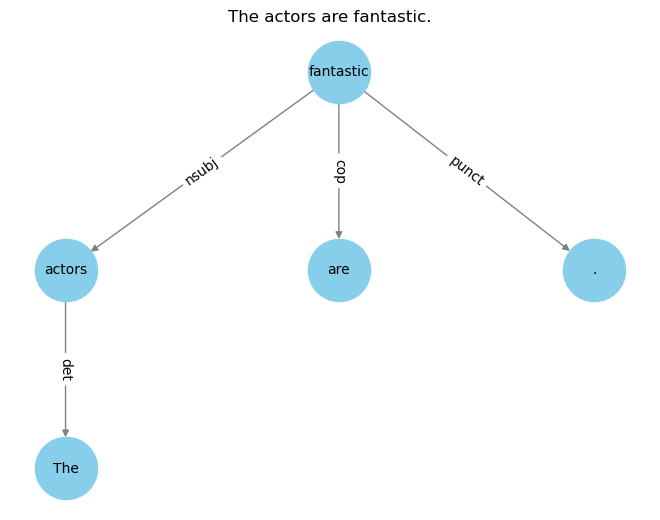

In [11]:
######################### Test ##################################
sentence = "The actors are fantastic."
G = create_graph(sentence)

nodes = G.nodes(data=True)
edges = G.edges(data=True)

pos = graphviz_layout(G, prog='dot')
node_labels = nx.get_node_attributes(G, 'label')
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw(G, pos, with_labels=True, labels=node_labels, node_size=2000, node_color="skyblue", font_size=10, edge_color="gray")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)
plt.title(sentence)
plt.show()
################################################################

### Node embeddings

In [12]:
node_embeddings = {}

### Propulate `node_embeddings` lookup dict

We use [GloVe](https://github.com/stanfordnlp/GloVe)
(42B tokens, 1.9M vocab, uncased, 300d vectors, 1.75 GB download)

You will need to download, unzip and upload it to a folder that Colab can access.

Download link: [glove.42B.300d.zip](https://huggingface.co/stanfordnlp/glove/resolve/main/glove.42B.300d.zip)

In [13]:
GLOVE_PATH = "glove.42B.300d.txt" # Update this path if not the runtime folder.

In [14]:
# Load Glove embeddings (Estimate 3 minutes to run)
with open(GLOVE_PATH, 'r', encoding='utf-8') as f:
  for line in f:
    values = line.split()
    word = values[0]
    emb = np.asarray(values[1:], dtype='double')
    node_embeddings[word] = emb

In [17]:
# Estimate 18 minutes to run on T4.
data = SentenceClassificationGraphDataset(raw_data=raw)

Total number of raw data: 130000
Processing 130000 samples for BERT encodings
BERT encodings processed.


C:\Users\denis\AppData\Local\Temp\ipykernel_7636\3074466897.py:18: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  return torch.tensor(embedding_vectors, dtype=torch.float)


Processed 107655 graph examples


# Model

## RGCN layer

In [18]:
import torch
from torch import nn
import torch.nn.functional as F
from torch_geometric.nn import RGCNConv

class RGCN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, dropout, num_relations, num_bases, aggr):
        super(RGCN, self).__init__()
        self.dropout = dropout
        self.convs = nn.ModuleList()

        if num_layers <= 1:
          self.convs.extend([RGCNConv(input_dim, output_dim, num_relations, num_bases=num_bases, aggr=aggr)])
        else:
          self.convs.extend([RGCNConv(input_dim, hidden_dim, num_relations, num_bases=num_bases, aggr=aggr) for _ in range(num_layers - 1)])
          self.convs.extend([RGCNConv(hidden_dim, output_dim, num_relations, num_bases=num_bases, aggr=aggr)])

        self.reset_parameters()

    def reset_parameters(self):
        for conv in self.convs:
          conv.reset_parameters()

    def forward(self, x, edge_index, edge_type):
        for i, conv in enumerate(self.convs):
          x = conv(x, edge_index, edge_type)
          if i < len(self.convs) - 1:
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout,training=self.training)

        return x

## RGAT layer



In [19]:
from torch_geometric.nn import RGATConv

class RGAT(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_heads, num_layers, dropout, num_relations, attention_mechanism='across-relation'):
        super(RGAT, self).__init__()
        self.dropout = dropout
        self.convs = torch.nn.ModuleList()

        self.convs.extend([RGATConv(input_dim,
                                    hidden_dim,
                                    heads=num_heads,
                                    dropout=dropout,
                                    num_relations=num_relations,
                                    edge_dim = 1,
                                    attention_mechanism=attention_mechanism,
                                    attention_mode="multiplicative-self-attention")])
        if num_layers > 1:
          self.convs.extend([RGATConv(hidden_dim * num_heads,
                                      hidden_dim,
                                      heads=num_heads,
                                      dropout=dropout,
                                      num_relations=num_relations,
                                      edge_dim = 1,
                                      attention_mechanism=attention_mechanism,
                                    attention_mode="multiplicative-self-attention")
                                      for _ in range(num_layers - 1)])

        self.reset_parameters()

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()

    def forward(self, x, edge_index, edge_type, edge_attr):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index, edge_type, edge_attr=edge_attr)
            if i < len(self.convs) - 1:
                x = F.relu(x)
                x = F.dropout(x, p=self.dropout,training=self.training)
        return x

## Fusion Layer

In [20]:
class FusionLayer(nn.Module):
    def __init__(self, dim_gnn, dim_bert, fused_dim):
        super(FusionLayer, self).__init__()
        self.dim_gnn = dim_gnn
        self.dim_bert = dim_bert
        self.fused_dim = fused_dim
        self.fc_gnn = nn.Linear(dim_gnn, fused_dim)
        self.fc_bert = nn.Linear(dim_bert, fused_dim)
        self.alpha = nn.Parameter(torch.tensor(0.5))  # Weight for GNN
        self.beta = nn.Parameter(torch.tensor(0.5))   # Weight for BERT
        self.reset_parameters()

    def reset_parameters(self):
        self.fc_gnn.reset_parameters()
        self.fc_bert.reset_parameters()
        nn.init.xavier_uniform_(self.fc_gnn.weight)
        nn.init.xavier_uniform_(self.fc_bert.weight)

    def forward(self, gnn_output, bert_output):
        gnn_transformed = self.fc_gnn(gnn_output) if self.dim_gnn != self.fused_dim else gnn_output
        bert_transformed = self.fc_bert(bert_output) if self.dim_bert != self.fused_dim else bert_output

        fused = self.alpha * gnn_transformed + self.beta * bert_transformed

        elementwise_interaction = gnn_transformed * bert_transformed

        output = fused + elementwise_interaction

        return output

## Global Attention with node weights

In [21]:

from torch_geometric.nn.inits import reset

class GlobalAttention(torch.nn.Module):
    def __init__(self, gate_nn, nn=None):
        super(GlobalAttention, self).__init__()
        self.gate_nn = gate_nn
        self.nn = nn

        self.reset_parameters()

    def reset_parameters(self):
        reset(self.gate_nn)
        reset(self.nn)

    def forward(self, x, batch, node_weights=None, size=None):
        x = x.unsqueeze(-1) if x.dim() == 1 else x
        size = batch[-1].item() + 1 if size is None else size

        gate = self.gate_nn(x).view(-1, 1) # Compute the attention gate scores
        gate = gate * node_weights.view(-1, 1) if node_weights is not None else gate # note weights

        x = self.nn(x) if self.nn is not None else x
        assert gate.dim() == x.dim() and gate.size(0) == x.size(0)

        gate = F.softmax(gate, batch, size)
        out = torch.zeros(size, x.size(1), device=x.device)
        out.index_add_(0, batch, gate * x)

        return out

## Final Model

In [22]:
from torch_geometric.nn import (
    global_add_pool,
    global_max_pool,
    global_mean_pool,
)

class GNNSentimentWithBERT(nn.Module):
    def __init__(self, args):
        super(GNNSentimentWithBERT, self).__init__()
        self.args = args
        self.bert = BertModel.from_pretrained('bert-base-uncased')

        if args.pretrain_model is not None:
          for param in self.bert.parameters():
              param.requires_grad = False # Freeze bert layers

        if args.num_rgcn_layers > 0:
          self.rgcn = RGCN(input_dim=args.hidden_dim,
                          hidden_dim=args.hidden_dim,
                          output_dim=args.hidden_dim,
                          num_layers=args.num_rgcn_layers,
                          dropout=args.dropout,
                          num_relations=len(UNIVERSAL_DEPENDENCY_RELATIONS),
                          num_bases=args.num_rgcn_bases,
                          aggr='sum')

        if args.num_rgat_layers > 0:
          self.rgat = RGAT(input_dim=args.hidden_dim,
                          hidden_dim=args.hidden_dim,
                          num_heads=args.num_rgat_heads,
                          num_layers=args.num_rgat_layers,
                          num_relations=len(UNIVERSAL_DEPENDENCY_RELATIONS),
                          dropout=args.dropout)

        self.gnn_enabled = args.num_rgcn_layers > 0 or args.num_rgat_layers > 0

        if args.graph_pooling == "sum":
            self.pool = global_add_pool
        elif args.graph_pooling == "mean":
            self.pool = global_mean_pool
        elif args.graph_pooling == "max":
            self.pool = global_max_pool
        elif args.graph_pooling == "attention":
            self.pool = GlobalAttention(
                gate_nn=torch.nn.Linear(args.hidden_dim, 1),
                nn=nn.Tanh()
              )
        else:
            print(f"Unknown pooling type: {args.graph_pooling}. Using mean pool.")
            self.pool = global_mean_pool

        self.sentence_layer = nn.Linear(BERT_HIDDEN_SIZE, BERT_HIDDEN_SIZE)

        self.fusion = FusionLayer(args.hidden_dim, BERT_HIDDEN_SIZE, BERT_HIDDEN_SIZE)

        self.gnn_sentiment = nn.Linear(
            BERT_HIDDEN_SIZE if args.concat_bert else args.hidden_dim*min(args.num_rgat_heads, 1),
            N_SENTIMENT_CLASSES)

    def forward(self, batch):
        x = batch.x

        if self.args.num_rgcn_layers > 0:
            x = self.rgcn(x, batch.edge_index, batch.edge_type)

        if self.args.num_rgat_layers > 0:
            x = self.rgat(x, batch.edge_index, batch.edge_type, edge_attr=batch.edge_weights)

        if self.gnn_enabled:
          x = self.graph_readout(x, batch)

        if self.args.concat_bert:
            sentence_embedding = self.get_sentence_embeddings(batch)
            sentence_embedding = self.sentence_layer(sentence_embedding)

            if self.gnn_enabled:
              x = self.fusion(x, sentence_embedding)
            else:
              x = sentence_embedding

            x = F.relu(x)
            x = F.dropout(x, p=self.args.dropout, training=self.training)

        logits = self.gnn_sentiment(x)
        return logits

    def graph_readout(self, x, batch):
        x = self.pool(x, batch.batch)
        if self.args.graph_pooling_activation == "relu":
            x = F.relu(x)
        elif self.args.graph_pooling_activation == "tanh":
            x = F.tanh(x)
        elif self.args.graph_pooling_activation == "sigmoid":
            x = F.sigmoid(x)
        if self.args.graph_pooling_dropout > 0:
            x = F.dropout(x, p=self.args.dropout, training=self.training)
        return x

    def get_sentence_embeddings(self, batch):
        batch_size = batch.batch.max().item() + 1
        seq_len = batch.sent_input_id.shape[0] // batch_size
        input_ids = batch.sent_input_id[:batch_size * seq_len]
        input_ids = input_ids.view(batch_size, seq_len)
        attention_mask = batch.sent_attention_mask[:batch_size * seq_len]
        attention_mask = attention_mask.view(batch_size, seq_len)

        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_token = outputs['pooler_output']
        return cls_token


# Training

In [23]:
def train(epoch, model, optimizer, sst_train_dataloader):
    y_true = []
    y_pred = []
    train_loss = 0

    model.train()
    for batch in tqdm(sst_train_dataloader, desc=f'train-SST-epoch-{epoch}', disable=TQDM_DISABLE):
        batch = batch.to(device)

        optimizer.zero_grad()
        logits = model(batch)
        loss = F.cross_entropy(logits, batch.y.view(-1))
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        with torch.no_grad(): # Train acc
          y_hat = logits.argmax(dim=-1).flatten().cpu().detach().numpy()
          y = batch.y.flatten().cpu().detach().numpy()
          y_pred.extend(y_hat)
          y_true.extend(y)

    train_acc = np.mean(np.array(y_pred) == np.array(y_true))

    return train_loss, train_acc

def eval(model, sentiment_dataloader):
    model.eval()
    with torch.no_grad():
        sst_y_true = []
        sst_y_pred = []
        sst_sent_ids = []
        for step, batch in enumerate(tqdm(sentiment_dataloader, desc=f'eval sst', disable=TQDM_DISABLE)):
          logits = model(batch)
          y_hat = logits.argmax(dim=-1).flatten().cpu().detach().numpy()
          y = batch.y.flatten().cpu().detach().numpy()
          sst_y_pred.extend(y_hat)
          sst_y_true.extend(y)
          sst_sent_ids.extend(batch.sent_id)

        eval_acc = np.mean(np.array(sst_y_pred) == np.array(sst_y_true))

        return eval_acc

def load_model(args):
    model = GNNSentimentWithBERT(args)
    model = model.to(device)

    if args.pretrain_model is not None:
        print(f"\nloaded the saved model from {args.pretrain_model} on device {device}.\n")
        saved = torch.load(args.pretrain_model, map_location=device, weights_only=False)
        model.load_state_dict(saved['model'], strict=False)

    return model

def save_model(model, optimizer, args, filename, best_dev_acc=0):
    args_save = copy.copy(args)
    save_info = {
        'model': model.state_dict(),
        'optim': optimizer.state_dict(),
        'args': args_save,
        'best_dev_acc': best_dev_acc,
        'system_rng': random.getstate(),
        'numpy_rng': np.random.get_state(),
        'torch_rng': torch.random.get_rng_state(),
    }

    os.makedirs(os.path.dirname(filename), exist_ok=True)
    torch.save(save_info, filename)
    print(f"saved the model to {filename}")

    # Also log score and args to a file for easier lookup.
    with open(f'{filename}_score_{round(best_dev_acc, 4)}.txt', "w") as f:
        f.write(f"{best_dev_acc}\n\n")
        f.write(" ".join([str(arg) for arg in vars(args).items()]))
        f.close()


Below are the hyperparameters and model configurations.

In [24]:
from types import SimpleNamespace

args = SimpleNamespace(**{
    "hidden_dim": 300, # node dim
    "log_folder": "runs/colab", # for saving log files. Remember to download your model file if you wish to reuse it, as the folder will be deleted after each runtime.

    ##############################
    # Hyperparameters:
    ##############################
    "epochs": 3,
    "batch_size": 16,
    "dropout": 0.5,
    "lr": 1e-5,
    "weight_decay": 0.0,

    ##############################
    # Model configurations:
    ##############################

    # Configs for RGCN layer
    "num_rgcn_layers": 1,
    "num_rgcn_bases": None,

    # Configs for RGAN layer
    "num_rgat_layers": 0,
    "num_rgat_heads": 0,

    # Configs for graph pooling
    "graph_pooling": "mean",
    "graph_pooling_activation": None,
    "graph_pooling_dropout": 0.0,

    # Whether to include sentence embeddings. If False, only GNN layers are used.
    "concat_bert": True,

    # Pre-trained model file path. If None, BERT layers will be trainable.
    "pretrain_model": None
    # "pretrain_model": "runs/BASELINE_2_N1_B16_1e-5/model.pt"
})

In [25]:
from torch_geometric.loader import DataLoader
##############################
# Load data
##############################
train_data = [data for data in data if data.split == "train"]
val_data = [data for data in data if data.split == "validation"]
print(f"Train samples: {len(train_data)}, Val samples: {len(val_data)}")

train_data_loader = DataLoader(train_data, shuffle=True, batch_size=args.batch_size)
val_data_loader = DataLoader(val_data, shuffle=False, batch_size=args.batch_size)

Train samples: 82891, Val samples: 16562


In [26]:
##############################
# Happy training
##############################
from torch.optim import AdamW

print(f"\nFinetuning with GNN on SST only with args: \n{args}")
start = time.time()

model = load_model(args)
optimizer = AdamW(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
best_dev_acc = 0

for epoch in range(args.epochs):
    train_loss, train_acc = train(epoch, model, optimizer, train_data_loader)
    eval_acc = eval(model, val_data_loader)

    if eval_acc > best_dev_acc:
        best_dev_acc = eval_acc
        save_model(model, optimizer, args, f"{args.log_folder}/model_{start}.pt", best_dev_acc)

    print("====================================")
    print(f"Epoch {epoch} train loss :: SST: {train_loss :.3f}")
    print(f"Epoch {epoch} train acc :: SST: {train_acc :.3f}")
    print(f"Epoch {epoch} eval acc :: SST: {eval_acc :.3f}, best_dev_acc: {best_dev_acc :.3f}")
    print("====================================")

print(f"{args.epochs} epoches finished in {round((time.time() - start)/60, 2)} minutes")



Finetuning with GNN on SST only with args: 
namespace(hidden_dim=300, log_folder='runs/colab', epochs=3, batch_size=16, dropout=0.5, lr=1e-05, weight_decay=0.0, num_rgcn_layers=1, num_rgcn_bases=None, num_rgat_layers=0, num_rgat_heads=0, graph_pooling='mean', graph_pooling_activation=None, graph_pooling_dropout=0.0, concat_bert=True, pretrain_model=None)


eval sst: 100%|██████████| 1036/1036 [01:28<00:00, 11.68it/s]


saved the model to runs/colab/model_1776333206.351327.pt
Epoch 0 train loss :: SST: 2060.138
Epoch 0 train acc :: SST: 0.821
Epoch 0 eval acc :: SST: 0.842, best_dev_acc: 0.842


eval sst: 100%|██████████| 1036/1036 [01:28<00:00, 11.72it/s]


saved the model to runs/colab/model_1776333206.351327.pt
Epoch 1 train loss :: SST: 1583.706
Epoch 1 train acc :: SST: 0.871
Epoch 1 eval acc :: SST: 0.846, best_dev_acc: 0.846


eval sst: 100%|██████████| 1036/1036 [01:26<00:00, 11.99it/s]

Epoch 2 train loss :: SST: 1127.763
Epoch 2 train acc :: SST: 0.912
Epoch 2 eval acc :: SST: 0.842, best_dev_acc: 0.846
3 epoches finished in 68.74 minutes


In [27]:
from sklearn.metrics import f1_score

In [29]:
test_data = [data for data in data if data.split == "test"]

In [30]:
test_data_loader = DataLoader(test_data, shuffle=False, batch_size=args.batch_size)

In [33]:
def eval(model, sentiment_dataloader):
    model.eval()
    with torch.no_grad():
        sst_y_true = []
        sst_y_pred = []
        sst_sent_ids = []
        for step, batch in enumerate(tqdm(sentiment_dataloader, desc=f'eval sst', disable=TQDM_DISABLE)):
          logits = model(batch)
          y_hat = logits.argmax(dim=-1).flatten().cpu().detach().numpy()
          y = batch.y.flatten().cpu().detach().numpy()
          sst_y_pred.extend(y_hat)
          sst_y_true.extend(y)
          sst_sent_ids.extend(batch.sent_id)

        eval_acc = np.mean(np.array(sst_y_pred) == np.array(sst_y_true))
        f1 = f1_score(sst_y_true, sst_y_pred, average='binary')

        return eval_acc,f1

In [38]:
args.pretrain_model = "runs\colab\model_1776333206.351327.pt"

model = load_model(args)


loaded the saved model from runs\colab\model_1776333206.351327.pt on device cuda.



In [ ]:
test_acc, test_f1 = eval(model, test_data_loader)

print("\n===== TEST RESULTS =====")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1-score: {test_f1:.4f}")

eval sst:  42%|████▏     | 213/513 [02:07<05:25,  1.09s/it]